In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [46]:
df = pd.read_csv('/content/titanic_toy.csv')

In [47]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [49]:
df.isnull().sum()

,0
Age,177
Fare,45
Family,0
Survived,0


In [50]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [52]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [53]:
X_train.isnull().sum()

,0
Age,140
Fare,36
Family,0


In [54]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [55]:
print("mean_age: ",mean_age )
print("median_age: ",median_age)

print("mean_fare",mean_fare)
print("median_age",median_fare)

mean_age:  29.498846153846156
median_age:  28.0
mean_fare 32.51778772189349
median_age 14.4


In [56]:
X_train['mean_age'] = X_train['Age'].fillna(mean_age)
X_train['median_age'] = X_train['Age'].fillna(median_age)

X_train['mean_fare'] = X_train['Fare'].fillna(mean_fare)
X_train['median_fare'] = X_train['Fare'].fillna(median_fare)

In [57]:
X_train.sample(5)

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
158,NaN,8.6625,0,29.498846,28.0,8.6625,8.6625
379,19.0,7.7750,0,19.000000,19.0,7.7750,7.7750
797,31.0,8.6833,0,31.000000,31.0,8.6833,8.6833
474,22.0,9.8375,0,22.000000,22.0,9.8375,9.8375
536,45.0,26.5500,0,45.000000,45.0,26.5500,26.5500


In [58]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after mean imputation: ', X_train['mean_age'].var())
print('Age Variance after median imputation: ', X_train['median_age'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after mean imputation: ', X_train['mean_fare'].var())
print('Fare Variance after median imputation: ', X_train['median_fare'].var())

Original Age variable variance:  210.2517072477438
Age Variance after mean imputation:  168.8519336687225
Age Variance after median imputation:  169.20731007048096
Original Fare variable variance:  2761.031434948639
Fare Variance after mean imputation:  2621.2323749512393
Fare Variance after median imputation:  2637.01248167777


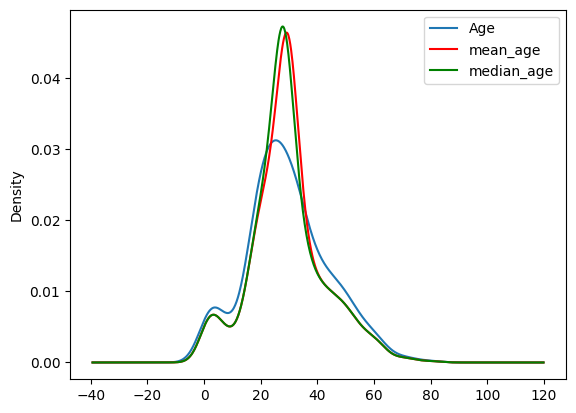

In [59]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variance diatribuion
X_train['Age'].plot(kind='kde', ax=ax)

# variable impute with the mean
X_train['mean_age'].plot(kind='kde', ax=ax, color='red')

# variableimpute with the median
X_train['median_age'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

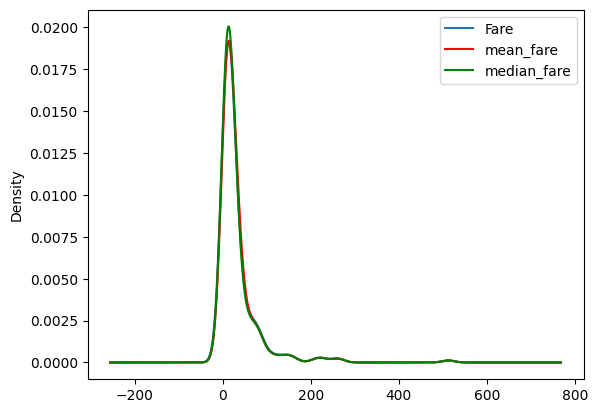

In [60]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variance diatribuion
X_train['Fare'].plot(kind='kde', ax=ax)

# variable impute with the mean
X_train['mean_fare'].plot(kind='kde', ax=ax, color='red')

# variableimpute with the median
X_train['median_fare'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [61]:
X_train.cov()

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,70.082085
Fare,75.481375,2761.031435,18.599163,60.224654,63.938058,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.616299,-5.587710,17.657433,17.672035
mean_age,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,56.282518
median_age,210.251707,63.938058,-5.587710,168.851934,169.207310,60.700688,59.728510
mean_fare,71.193767,2761.031435,17.657433,57.175304,60.700688,2621.232375,2621.232375
median_fare,70.082085,2761.031435,17.672035,56.282518,59.728510,2621.232375,2637.012482


In [62]:
X_train.corr()

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088944,0.087232
Fare,0.091482,1.000000,0.207193,0.088151,0.093496,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,-0.255307,0.204981,0.204536
mean_age,1.000000,0.088151,-0.256883,1.000000,0.998949,0.085941,0.084346
median_age,1.000000,0.093496,-0.255307,0.998949,1.000000,0.091145,0.089416
mean_fare,0.088944,1.000000,0.204981,0.085941,0.091145,1.000000,0.997003
median_fare,0.087232,1.000000,0.204536,0.084346,0.089416,0.997003,1.000000


<Axes: >

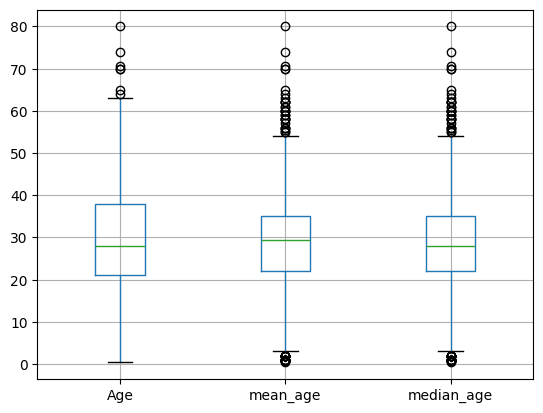

In [63]:
X_train[['Age', 'mean_age', 'median_age']].boxplot()

<Axes: >

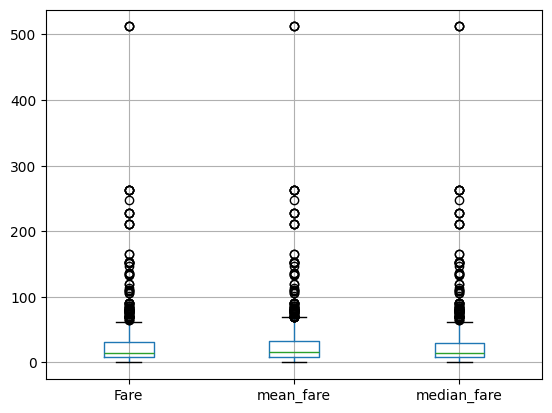

In [64]:
X_train[['Fare', 'mean_fare', 'median_fare']].boxplot()

# using sklearn

In [65]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [66]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [67]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
],remainder='passthrough')

In [68]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [69]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [70]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [71]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [72]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])

In [73]:
X_test

array([[ 42.        ,  26.2875    ,   0.        ],
       [ 21.        ,   8.05      ,   0.        ],
       [ 24.        ,  65.        ,   3.        ],
       [ 28.        ,  56.4958    ,   0.        ],
       [ 17.        ,   7.925     ,   6.        ],
       [ 30.        ,   7.8958    ,   0.        ],
       [ 80.        ,  30.        ,   0.        ],
       [ 25.        ,   7.25      ,   0.        ],
       [ 50.        , 133.65      ,   2.        ],
       [ 25.        ,  26.        ,   1.        ],
       [ 35.        ,  26.        ,   0.        ],
       [ 35.        ,  90.        ,   1.        ],
       [ 55.        ,  16.        ,   0.        ],
       [ 28.75      ,  56.4958    ,   0.        ],
       [ 28.75      ,  56.4958    ,   0.        ],
       [ 19.        ,   7.8542    ,   1.        ],
       [ 28.75      ,  15.2458    ,   2.        ],
       [ 49.        ,   0.        ,   0.        ],
       [ 18.        ,  32.61759689,   1.        ],
       [ 65.        ,   7.75   